
Call Center Analysis Results:
Mean call duration: 8.04 minutes
Standard deviation: 1.96 minutes

Empirical Rule Verification:
Percentage within 1 SD: 68.6% (expected ~68%)
Percentage within 2 SD: 95.6% (expected ~95%)
Percentage within 3 SD: 99.7% (expected ~99.7%)

Probability of call exceeding 10 minutes: 15.8%

Staffing Recommendation:
Minimum agents needed for 30 calls per hour: 5


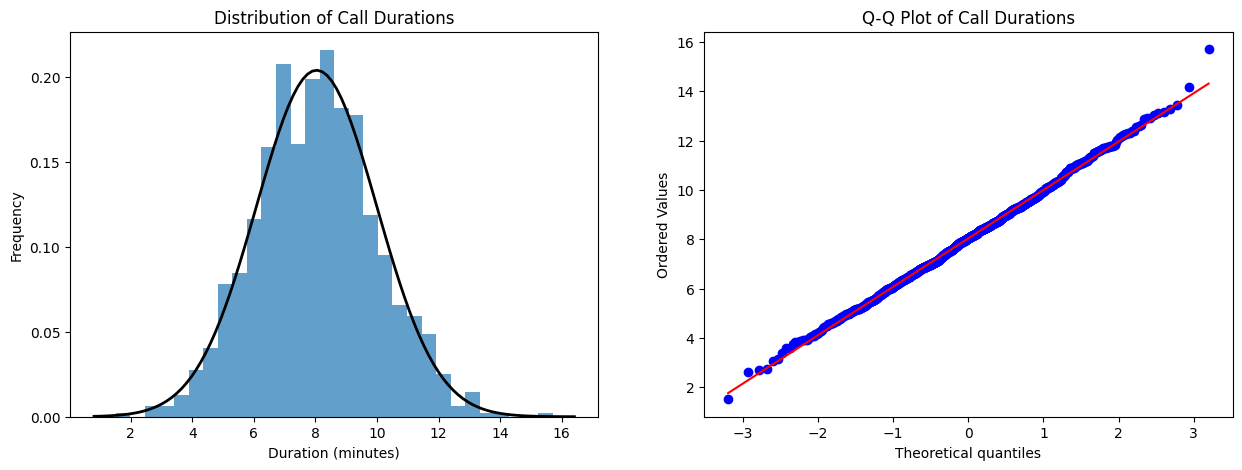

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy import stats

def analyze_call_durations(call_data, target_duration=None):
    """
    Analyze call center duration data assuming normal distribution
    
    Parameters:
    call_data: array-like, call durations in minutes
    target_duration: float, optional target duration for SLA
    """
    
    # Step 1: Verify Normal Distribution Appropriateness
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram with normal curve overlay
    hist_data = ax1.hist(call_data, bins=30, density=True, alpha=0.7)
    xmin, xmax = ax1.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(call_data), np.std(call_data))
    ax1.plot(x, p, 'k', linewidth=2)
    ax1.set_title('Distribution of Call Durations')
    ax1.set_xlabel('Duration (minutes)')
    ax1.set_ylabel('Frequency')
    
    # Q-Q plot
    stats.probplot(call_data, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot of Call Durations')
    
    # Step 2: Characterize the Distribution
    mean_duration = np.mean(call_data)
    std_duration = np.std(call_data)
    
    # Step 3: Calculate Key Statistics
    results = {
        'mean': mean_duration,
        'std': std_duration,
        'within_1_std': np.mean(np.abs(call_data - mean_duration) <= std_duration),
        'within_2_std': np.mean(np.abs(call_data - mean_duration) <= 2 * std_duration),
        'within_3_std': np.mean(np.abs(call_data - mean_duration) <= 3 * std_duration)
    }
    
    # Step 4: Calculate SLA Probabilities if target provided
    if target_duration is not None:
        z_score = (target_duration - mean_duration) / std_duration
        prob_within_target = 1 - stats.norm.cdf(z_score)
        results['probability_exceed_target'] = prob_within_target
    
    return results


# Generate sample call data (normally distributed)
np.random.seed(42)
call_durations = np.random.normal(loc=8, scale=2, size=1000)

# Analyze the data with a target SLA of 10 minutes
results = analyze_call_durations(call_durations, target_duration=10)

# Print results
print("\nCall Center Analysis Results:")
print(f"Mean call duration: {results['mean']:.2f} minutes")
print(f"Standard deviation: {results['std']:.2f} minutes")
print(f"\nEmpirical Rule Verification:")
print(f"Percentage within 1 SD: {results['within_1_std']*100:.1f}% (expected ~68%)")
print(f"Percentage within 2 SD: {results['within_2_std']*100:.1f}% (expected ~95%)")
print(f"Percentage within 3 SD: {results['within_3_std']*100:.1f}% (expected ~99.7%)")
print(f"\nProbability of call exceeding 10 minutes: {results['probability_exceed_target']*100:.1f}%")


# Step 5: Calculate staffing implications
def calculate_staffing_needs(mean_duration, calls_per_hour, target_occupancy=0.85):
    """Calculate required staff based on Erlang C formula simplified"""
    service_rate = 60 / mean_duration
    minimum_agents = np.ceil(calls_per_hour / (service_rate * target_occupancy))
    return int(minimum_agents)

calls_per_hour = 30
staff_needed = calculate_staffing_needs(results['mean'], calls_per_hour)
print(f"\nStaffing Recommendation:")
print(f"Minimum agents needed for {calls_per_hour} calls per hour: {staff_needed}")